# IMPORT STATEMENTS

In [1]:
import os
import json
import copy
import time
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms
from tqdm.notebook import tqdm, trange
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# PATHS AND VARIABLES

In [22]:
DATA_DIR = "../data/combined-dataset-true"
WEIGHTS_PATH = f"{DATA_DIR}/class_weights.json"
NUM_CLASSES = 31
MODEL_NAME = "mlp_shallow"
IMAGE_SIZE = 64
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

In [23]:
os.makedirs("../visualizations-true", exist_ok=True)
os.makedirs(f"../visualizations-true/{MODEL_NAME}", exist_ok=True)
sns.set_theme(style="whitegrid")

# SET DEVICE

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


# BASIC MULTILAYER PERCEPTRON

In [25]:
class MLP_Shallow(nn.Module):
    def __init__(self, num_classes=16):
        super(MLP_Shallow, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(12288, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.network(self.flatten(x))

# DEFINE TRANSFORMS

In [26]:
train_transform = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

In [27]:
eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# CREATE DATALOADERS

In [28]:
train_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=transforms.Compose(train_transform))
val_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=eval_transform) 

In [29]:
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(0.2 * dataset_size))

np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

In [30]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_indices), num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(val_indices), num_workers=4, pin_memory=True)

In [31]:
print(f"Loading data at resolution: {IMAGE_SIZE}x{IMAGE_SIZE}.")
print(f"Train Size: {len(train_indices)} | Val Size: {len(val_indices)}")

Loading data at resolution: 64x64.
Train Size: 2751 | Val Size: 687


# INITIALIZE MODEL AND WEIGHTS

In [32]:
model = MLP_Shallow(NUM_CLASSES)
print(f"Initializing {MODEL_NAME.upper()}...")
model = model.to(device)

Initializing MLP_SHALLOW...


In [33]:
with open(WEIGHTS_PATH, "r") as f:
    weight_dict = json.load(f)
class_names = train_dataset.classes
weights_list = [weight_dict[c] for c in class_names]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(device)
class_weights_tensor

tensor([0.9814, 0.5630, 0.5837, 2.0925, 1.7888, 1.0463, 2.3596, 0.8402, 1.7888,
        0.4299, 0.5963, 1.9457, 1.9804, 1.0767, 1.9457, 1.0175, 1.1433, 2.9185,
        0.9902, 1.9457, 0.8944, 1.2603, 1.0562, 0.6804, 0.6975, 0.6641, 2.5205,
        1.7888, 1.5843, 0.7443, 0.5158], device='cuda:0')

In [42]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# SET EARLY STOPPING FEATURES

In [41]:
patience = 5
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [40]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# TRAINING LOOP

In [43]:
start_time = time.time()

epoch_pbar = trange(NUM_EPOCHS, desc=f"Training {MODEL_NAME.upper()}", unit="epoch")

for epoch in epoch_pbar:
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0
        dataset_size = len(dataloader.sampler)

        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [{phase.capitalize()}]", leave=False)

        for inputs, labels in batch_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
            
            tqdm.write(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                       f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
                       f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

    if patience_counter >= patience:
        tqdm.write(f"Early stopping triggered at epoch {epoch+1}!")
        break

time_elapsed = time.time() - start_time
print(f'\n{MODEL_NAME.upper()} Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

Training MLP_SHALLOW:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 3.4550 Acc: 0.1465 | Val Loss: 7.4563 Acc: 0.0771


Epoch 2 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

...

Epoch 10 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/30 | Train Loss: 2.9949 Acc: 0.1839 | Val Loss: 6.7900 Acc: 0.0830


Epoch 11 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 11 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 11/30 | Train Loss: 2.9379 Acc: 0.1803 | Val Loss: 5.9827 Acc: 0.0699
Early stopping triggered at epoch 11!

MLP_SHALLOW Training complete in 7m 43s


# LEARNING CURVE

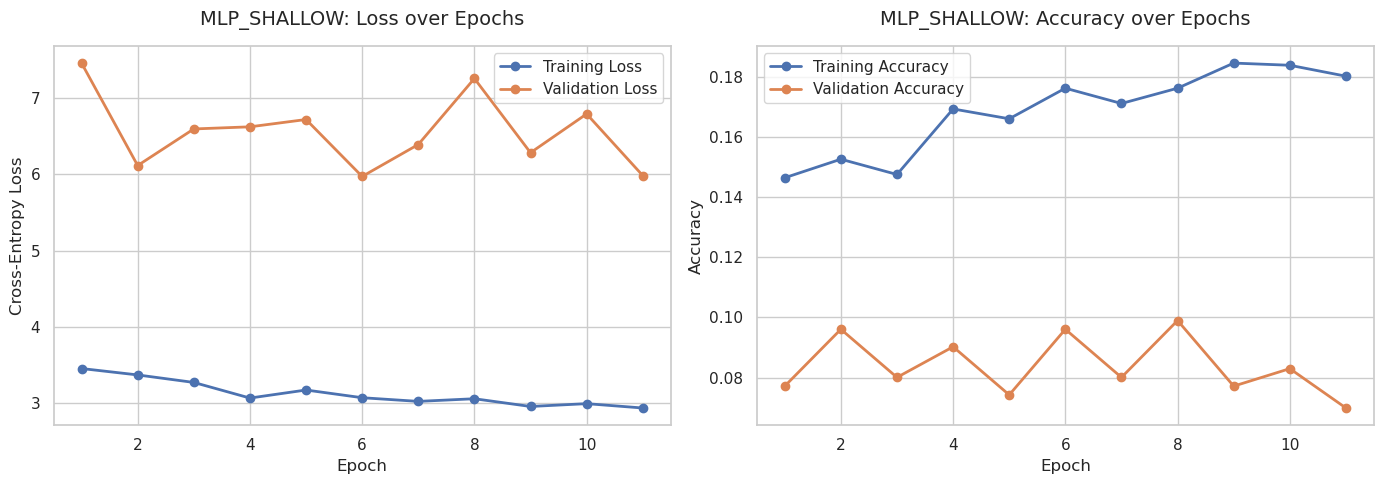

In [44]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='o', linewidth=2)
plt.title(f'{MODEL_NAME.upper()}: Loss over Epochs', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(range(1, len(val_accs) + 1), val_accs, label='Validation Accuracy', marker='o', linewidth=2)
plt.title(f'{MODEL_NAME.upper()}: Accuracy over Epochs', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

In [45]:
save_path = f"../visualizations-true/{MODEL_NAME}/{MODEL_NAME}_learning_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Learning curves saved successfully to {save_path}")
plt.show()

Learning curves saved successfully to ../visualizations-true/mlp_shallow/mlp_shallow_learning_curve.png


<Figure size 640x480 with 0 Axes>

# SAVE BEST MODEL WEIGHTS

In [46]:
os.makedirs("../models-true", exist_ok=True)
os.makedirs(f"../models-true/{MODEL_NAME}", exist_ok=True)
save_path = f"../models-true/{MODEL_NAME}/{MODEL_NAME}_best.pth"
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), save_path)
print(f"Best weights saved to {save_path}")

Best weights saved to ../models-true/mlp_shallow/mlp_shallow_best.pth


# TESTING

In [47]:
MODEL_WEIGHTS_PATH = f"../models-true/{MODEL_NAME}/{MODEL_NAME}_best.pth"
print(f"Evaluating on device: {device}")

Evaluating on device: cuda


# DEFINE TRANSFORM

In [48]:
test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# CREATE DATALOADER

In [49]:
test_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [50]:
class_names = test_dataset.classes
print(f"Loaded {len(test_dataset)} test images across {len(class_names)} classes.")

Loaded 434 test images across 31 classes.


# LOAD MODEL WEIGHTS

In [51]:
model = MLP_Shallow(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f"Successfully loaded {MODEL_NAME} weights from disk.")

Successfully loaded mlp_shallow weights from disk.


/tmp/ipykernel_18310/31405170.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))


In [52]:
all_preds = []
all_labels = []
all_probs = []

# GENERATE PREDICTIONS

In [53]:
print("Generating predictions...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Generating predictions...


# CLASSIFICATION REPORT

In [54]:
print(f"CLASSIFICATION REPORT: {MODEL_NAME.upper()}")
report_text = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report_text)

CLASSIFICATION REPORT: MLP_SHALLOW
                            precision    recall  f1-score   support

                apple leaf     0.3333    0.0500    0.0870        20
           apple rust leaf     0.1875    0.0938    0.1250        32
           apple scab leaf     0.0000    0.0000    0.0000        32
          bell pepper leaf     0.0800    0.2500    0.1212         8
     bell pepper leaf spot     0.0625    0.1111    0.0800         9
            blueberry leaf     0.0741    0.1818    0.1053        11
               cherry leaf     0.0000    0.0000    0.0000        10
       corn gray leaf spot     0.1250    0.0667    0.0870        15
                 corn leaf     0.1290    0.3636    0.1905        11
          corn leaf blight     0.0000    0.0000    0.0000        23
            corn rust leaf     0.2500    0.0952    0.1379        21
                grape leaf     0.0323    0.0833    0.0465        12
      grape leaf black rot     0.1429    0.3750    0.2069         8
            

/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [55]:
with open(f"../visualizations-true/{MODEL_NAME}/report.txt", "w") as f:
    f.write(f"Classification Report for {MODEL_NAME.upper()}\n\n")
    f.write(report_text)

In [56]:
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(f"../visualizations-true/{MODEL_NAME}/report.csv")
print(f"Metrics saved to ../visualizations-true/{MODEL_NAME}/report.csv")

Metrics saved to ../visualizations-true/mlp_shallow/report.csv


/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

# CONFUSION MATRIX

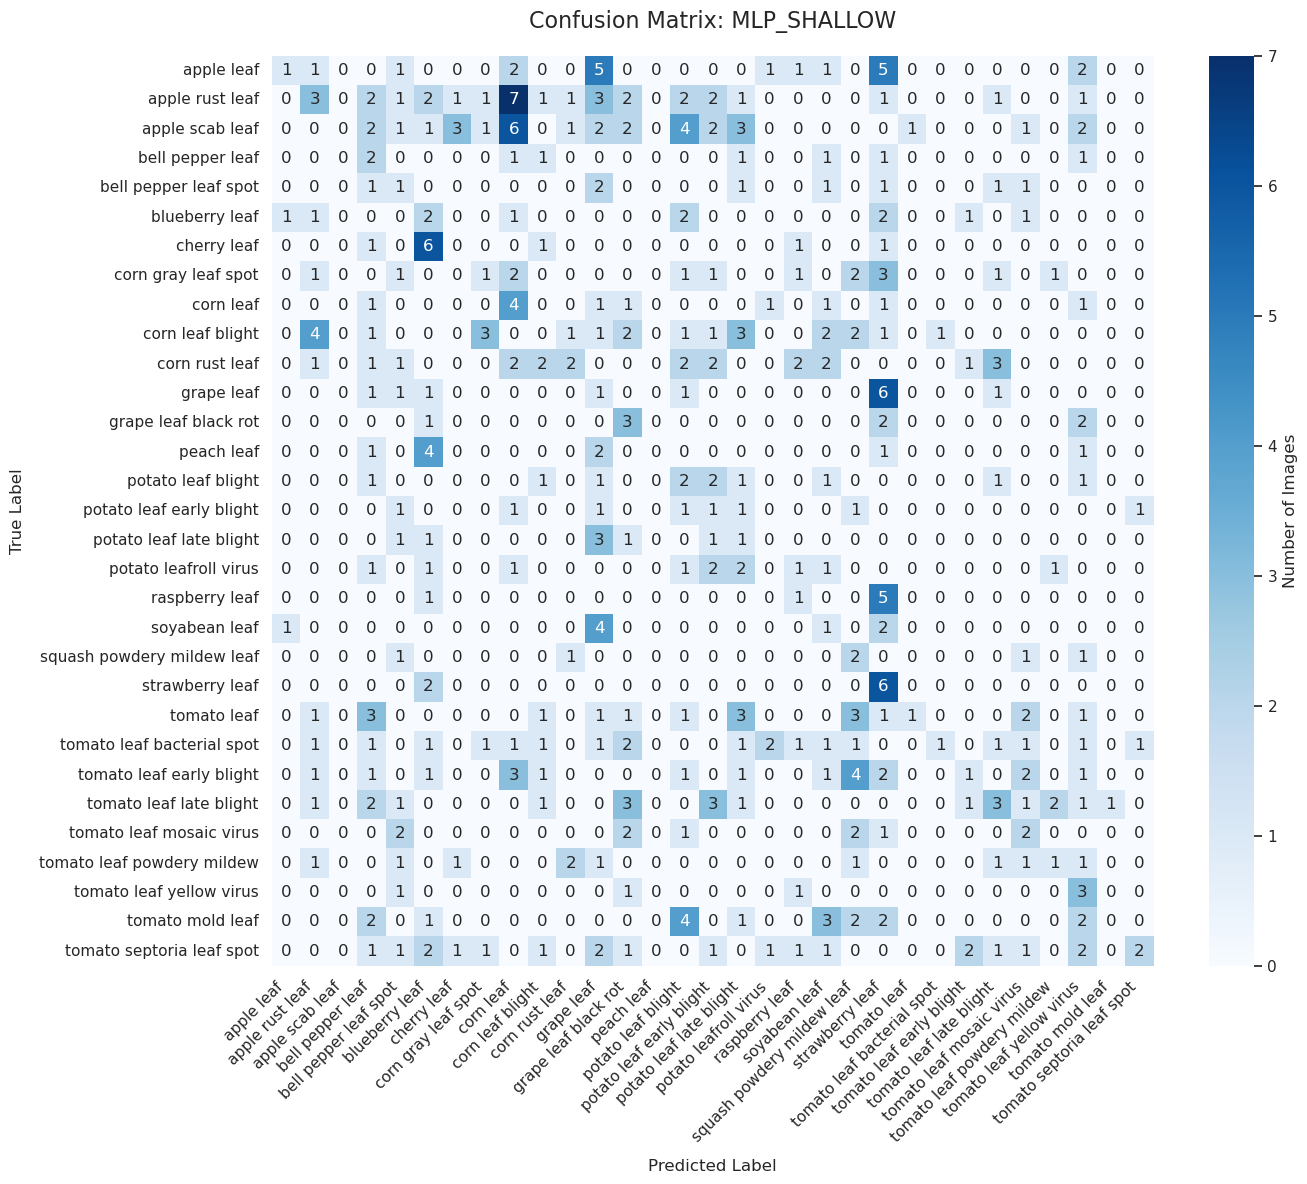

In [57]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Number of Images'})
plt.title(f'Confusion Matrix: {MODEL_NAME.upper()}', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../visualizations-true/{MODEL_NAME}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# AUC ROC CURVE

In [58]:
n_classes = len(class_names)
y_bin = label_binarize(all_labels, classes=range(n_classes))
all_probs = np.array(all_probs)

In [59]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

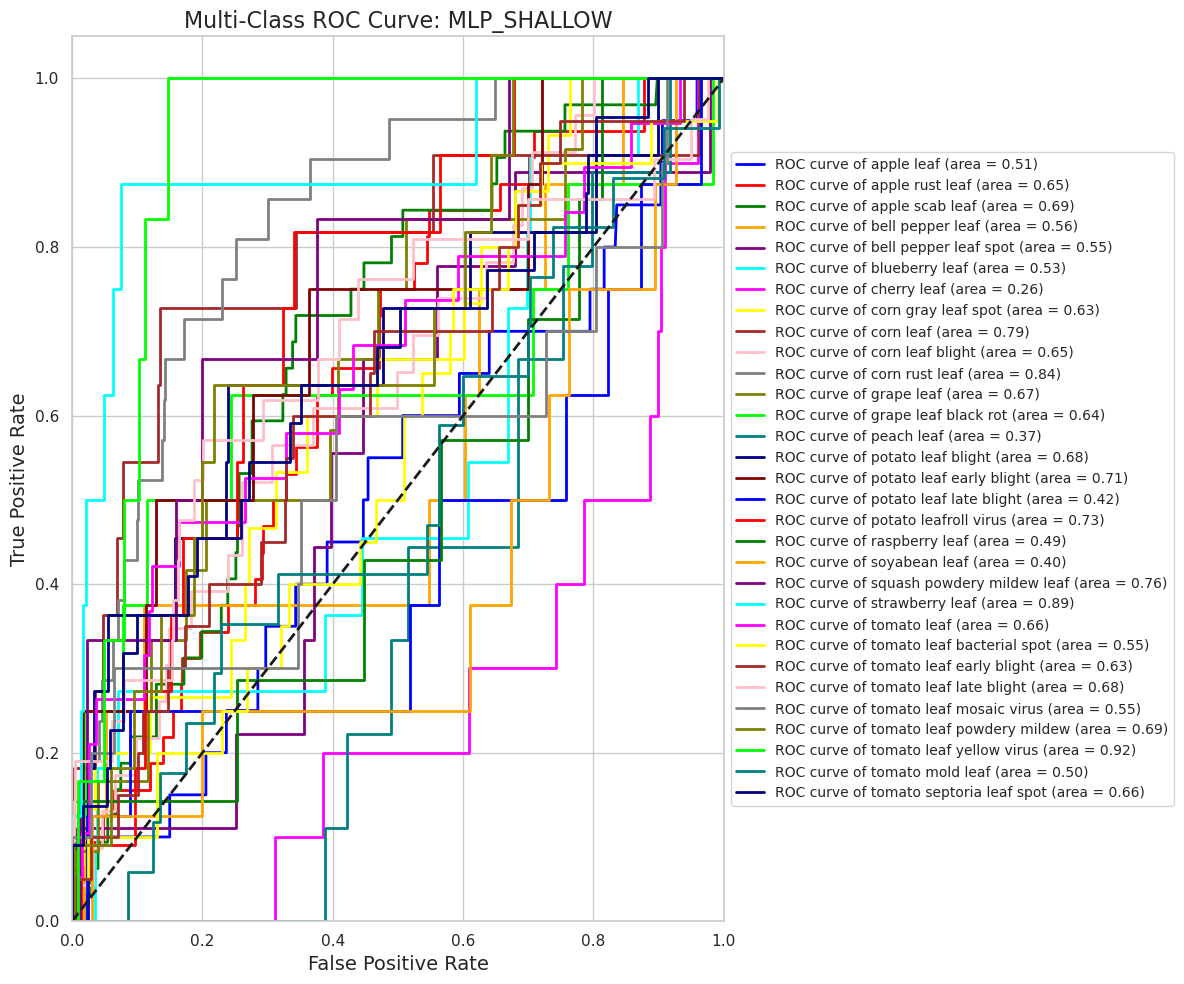

In [60]:
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive', 'lime', 'teal', 'navy', 'maroon'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title(f'Multi-Class ROC Curve: {MODEL_NAME.upper()}', fontsize=16)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.savefig(f"../visualizations-true/{MODEL_NAME}/{MODEL_NAME}_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()